Problem Statement - 
Parkinson’s Disease (PD) is a degenerative neurological disorder marked by decreased dopamine levels in the brain. It manifests itself through a deterioration of movement, including the presence of tremors and stiffness. There is commonly a marked effect on speech, including dysarthria (difficulty articulating sounds), hypophonia (lowered volume), and monotone (reduced pitch range). Additionally, cognitive impairments and changes in mood can occur, and risk of dementia is increased.

Traditional diagnosis of Parkinson’s Disease involves a clinician taking a neurological history of the patient and observing motor skills in various situations. Since there is no definitive laboratory test to diagnose PD, diagnosis is often difficult, particularly in the early stages when motor effects are not yet severe. Monitoring progression of the disease over time requires repeated clinic visits by the patient. An effective screening process, particularly one that doesn’t require a clinic visit, would be beneficial. Since PD patients exhibit characteristic vocal features, voice recordings are a useful and non-invasive tool for diagnosis. If machine learning algorithms could be applied to a voice recording dataset to accurately diagnosis PD, this would be an effective screening step prior to an appointment with a clinician.

The data & attributes information for this project is available at https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/ (Links to an external site.)Links to an external site. The data consists of those diagnosed with Parkinson Disease and those who do not.

Attribute Information:

Matrix column entries (attributes):
name - ASCII subject name and recording number
MDVP:Fo(Hz) - Average vocal fundamental frequency
MDVP:Fhi(Hz) - Maximum vocal fundamental frequency
MDVP:Flo(Hz) - Minimum vocal fundamental frequency
MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Several 
measures of variation in fundamental frequency
MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA - Several measures of variation in amplitude
NHR,HNR - Two measures of ratio of noise to tonal components in the voice
status - Health status of the subject (one) - Parkinson's, (zero) - healthy
RPDE,D2 - Two nonlinear dynamical complexity measures
DFA - Signal fractal scaling exponent
spread1,spread2,PPE - Three nonlinear measures of fundamental frequency variation 

Reasearch - Participants underwent voice recording. Perceptual evaluation was made using GRBASI scale, which considers G as the overall degree of dysphonia, R as roughness, B as breathiness, A as asthenia, S as strain and I as instability. The acoustic parameters analyzed were: fundamental frequency, jitter, shimmer, and harmonic to noise ratio (NHR). For vocal self-perception analysis, we used the Voice Related Quality of Life protocol.
RESULTS:

Fundamental frequency and jitter presented higher values in the Parkinson's group. NHR values were higher in the Control Group. Perceptual analysis showed a deviation ranging. The vocal disorder self-perception demonstrated a worse impact on quality of life.
CONCLUSIONS:

Individuals with Parkinson's disease have an altered voice quality and a negative impact on quality of life.

In [1]:
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn import metrics
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline

#from sklearn.decomposition import PCA
from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

/Applications/anaconda3/lib/python3.7/site-packages/sklearn/ensemble/weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d


Step 1 - Use a Python notebook & Load the dataset

In [4]:
df = pd.read_csv("parkinsons.data") 

Step 2 - It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset.

In [9]:
df.shape

(195, 24)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

Observations -
1. No Missing value
2. Dependant variable and Outcome is "Status" - Health status of the subject (one) - Parkinson's, (zero) - healthy


In [12]:
df.head().T

,0,1,2,3,4
name,phon_R01_S01_1,phon_R01_S01_2,phon_R01_S01_3,phon_R01_S01_4,phon_R01_S01_5
MDVP:Fo(Hz),119.992,122.4,116.682,116.676,116.014
MDVP:Fhi(Hz),157.302,148.65,131.111,137.871,141.781
MDVP:Flo(Hz),74.997,113.819,111.555,111.366,110.655
MDVP:Jitter(%),0.00784,0.00968,0.0105,0.00997,0.01284
MDVP:Jitter(Abs),7e-05,8e-05,9e-05,9e-05,0.00011
MDVP:RAP,0.0037,0.00465,0.00544,0.00502,0.00655
MDVP:PPQ,0.00554,0.00696,0.00781,0.00698,0.00908
Jitter:DDP,0.01109,0.01394,0.01633,0.01505,0.01966
MDVP:Shimmer,0.04374,0.06134,0.05233,0.05492,0.06425


In [14]:
df.tail().T

,190,191,192,193,194
name,phon_R01_S50_2,phon_R01_S50_3,phon_R01_S50_4,phon_R01_S50_5,phon_R01_S50_6
MDVP:Fo(Hz),174.188,209.516,174.688,198.764,214.289
MDVP:Fhi(Hz),230.978,253.017,240.005,396.961,260.277
MDVP:Flo(Hz),94.261,89.488,74.287,74.904,77.973
MDVP:Jitter(%),0.00459,0.00564,0.0136,0.0074,0.00567
MDVP:Jitter(Abs),3e-05,3e-05,8e-05,4e-05,3e-05
MDVP:RAP,0.00263,0.00331,0.00624,0.0037,0.00295
MDVP:PPQ,0.00259,0.00292,0.00564,0.0039,0.00317
Jitter:DDP,0.0079,0.00994,0.01873,0.01109,0.00885
MDVP:Shimmer,0.04087,0.02751,0.02308,0.02296,0.01884


In [15]:
print(df.describe().transpose())

                  count        mean        std         min         25%  \
MDVP:Fo(Hz)       195.0  154.228641  41.390065   88.333000  117.572000   
MDVP:Fhi(Hz)      195.0  197.104918  91.491548  102.145000  134.862500   
MDVP:Flo(Hz)      195.0  116.324631  43.521413   65.476000   84.291000   
MDVP:Jitter(%)    195.0    0.006220   0.004848    0.001680    0.003460   
MDVP:Jitter(Abs)  195.0    0.000044   0.000035    0.000007    0.000020   
MDVP:RAP          195.0    0.003306   0.002968    0.000680    0.001660   
MDVP:PPQ          195.0    0.003446   0.002759    0.000920    0.001860   
Jitter:DDP        195.0    0.009920   0.008903    0.002040    0.004985   
MDVP:Shimmer      195.0    0.029709   0.018857    0.009540    0.016505   
MDVP:Shimmer(dB)  195.0    0.282251   0.194877    0.085000    0.148500   
Shimmer:APQ3      195.0    0.015664   0.010153    0.004550    0.008245   
Shimmer:APQ5      195.0    0.017878   0.012024    0.005700    0.009580   
MDVP:APQ          195.0    0.024081   

Step 3 - Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? 

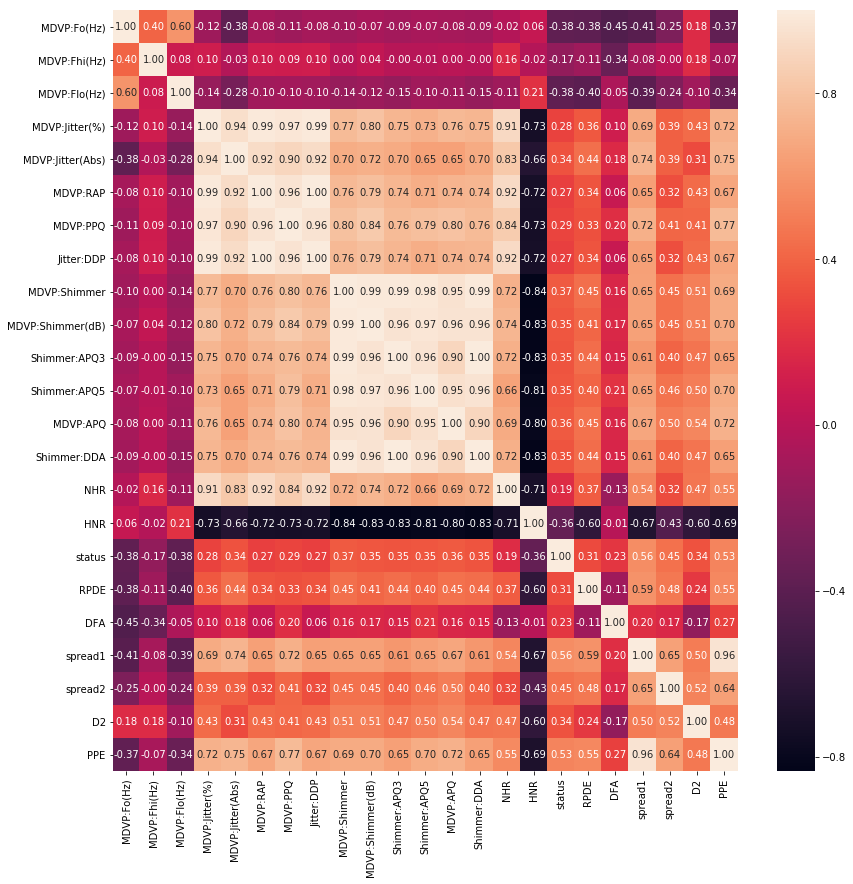

In [22]:
#correlation data
f,ax=plt.subplots(figsize=(14,14))
sns.heatmap(df.corr(),annot=True,ax=ax,fmt=".2f")
plt.xticks(rotation=90)
plt.show()

/Applications/anaconda3/lib/python3.7/site-packages/seaborn/axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


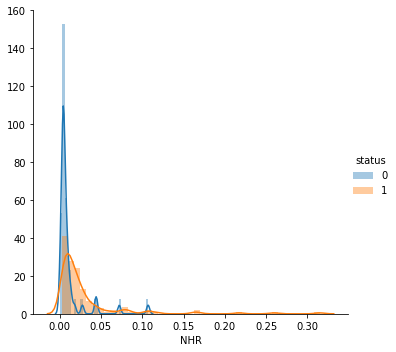

In [20]:
# Univariate Analysis
sns.FacetGrid(df, hue='status', size=5).map(sns.distplot, "NHR").add_legend()

In [ ]:
Observation - there is lot of variation in NHR for 

/Applications/anaconda3/lib/python3.7/site-packages/seaborn/axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


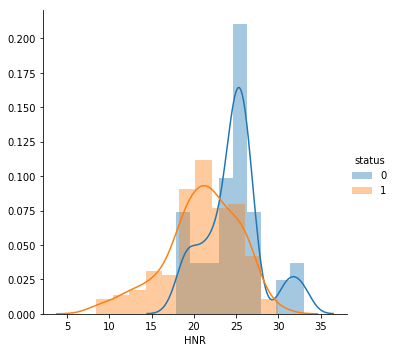

In [21]:
sns.FacetGrid(df, hue='status', size=5).map(sns.distplot, "HNR").add_legend()

/Applications/anaconda3/lib/python3.7/site-packages/seaborn/axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


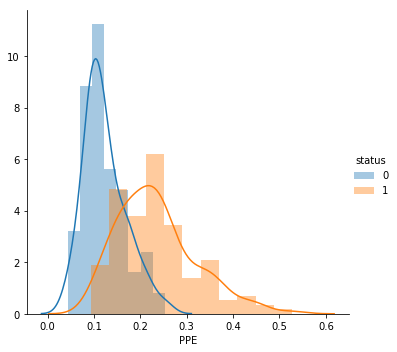

In [24]:
sns.FacetGrid(df, hue='status', size=5).map(sns.distplot, "PPE").add_legend()

/Applications/anaconda3/lib/python3.7/site-packages/seaborn/axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


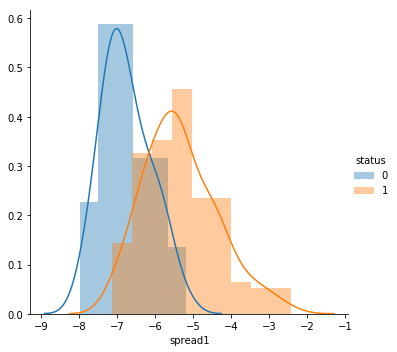

In [25]:
sns.FacetGrid(df, hue='status', size=5).map(sns.distplot, "spread1").add_legend()

/Applications/anaconda3/lib/python3.7/site-packages/seaborn/axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


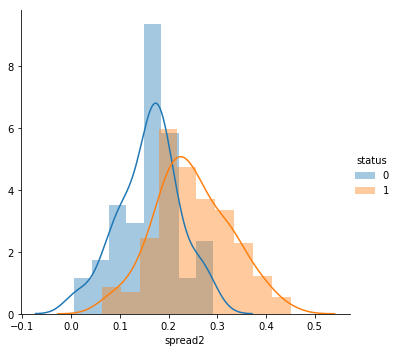

In [26]:
sns.FacetGrid(df, hue='status', size=5).map(sns.distplot, "spread2").add_legend()

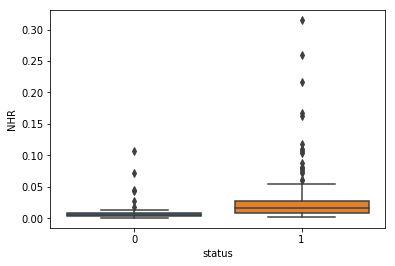

In [28]:
# Bivariate Analysis
sns.boxplot(x='status',y='NHR',data=df)

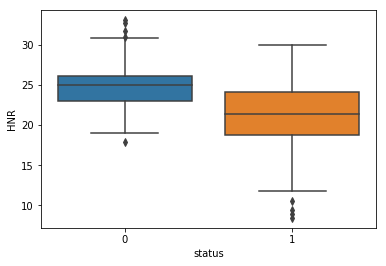

In [30]:
sns.boxplot(x='status',y='HNR',data=df)

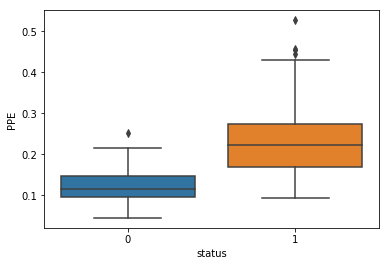

In [31]:
sns.boxplot(x='status',y='PPE',data=df)

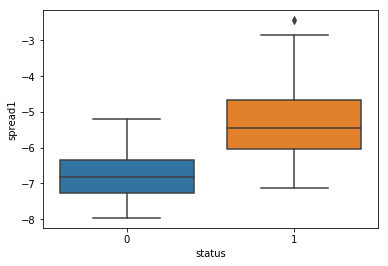

In [32]:
sns.boxplot(x='status',y='spread1',data=df)

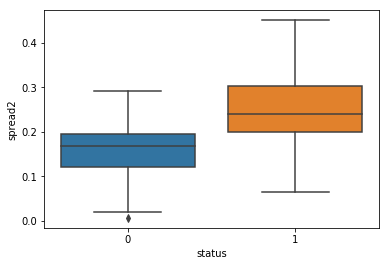

In [33]:
sns.boxplot(x='status',y='spread2',data=df)

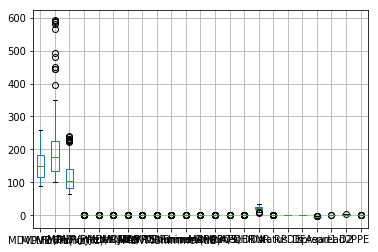

In [55]:
df.boxplot()

Removing Outlier

In [56]:
def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

In [57]:
df1 = remove_outlier(df, 'MDVP:Fhi(Hz)')

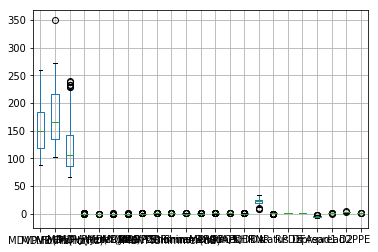

In [58]:
df1.boxplot()

In [60]:
print(df1.info())
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 184 entries, 0 to 194
Data columns (total 24 columns):
name                184 non-null object
MDVP:Fo(Hz)         184 non-null float64
MDVP:Fhi(Hz)        184 non-null float64
MDVP:Flo(Hz)        184 non-null float64
MDVP:Jitter(%)      184 non-null float64
MDVP:Jitter(Abs)    184 non-null float64
MDVP:RAP            184 non-null float64
MDVP:PPQ            184 non-null float64
Jitter:DDP          184 non-null float64
MDVP:Shimmer        184 non-null float64
MDVP:Shimmer(dB)    184 non-null float64
Shimmer:APQ3        184 non-null float64
Shimmer:APQ5        184 non-null float64
MDVP:APQ            184 non-null float64
Shimmer:DDA         184 non-null float64
NHR                 184 non-null float64
HNR                 184 non-null float64
status              184 non-null int64
RPDE                184 non-null float64
DFA                 184 non-null float64
spread1             184 non-null float64
spread2             184 non-null floa

In [61]:
df1 = remove_outlier(df1, 'MDVP:Flo(Hz)')

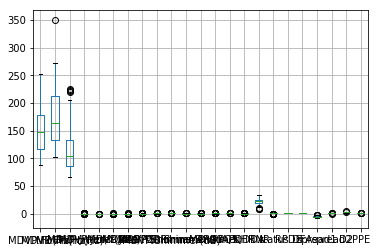

In [62]:
df1.boxplot()

In [64]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 177 entries, 0 to 194
Data columns (total 24 columns):
name                177 non-null object
MDVP:Fo(Hz)         177 non-null float64
MDVP:Fhi(Hz)        177 non-null float64
MDVP:Flo(Hz)        177 non-null float64
MDVP:Jitter(%)      177 non-null float64
MDVP:Jitter(Abs)    177 non-null float64
MDVP:RAP            177 non-null float64
MDVP:PPQ            177 non-null float64
Jitter:DDP          177 non-null float64
MDVP:Shimmer        177 non-null float64
MDVP:Shimmer(dB)    177 non-null float64
Shimmer:APQ3        177 non-null float64
Shimmer:APQ5        177 non-null float64
MDVP:APQ            177 non-null float64
Shimmer:DDA         177 non-null float64
NHR                 177 non-null float64
HNR                 177 non-null float64
status              177 non-null int64
RPDE                177 non-null float64
DFA                 177 non-null float64
spread1             177 non-null float64
spread2             177 non-null floa

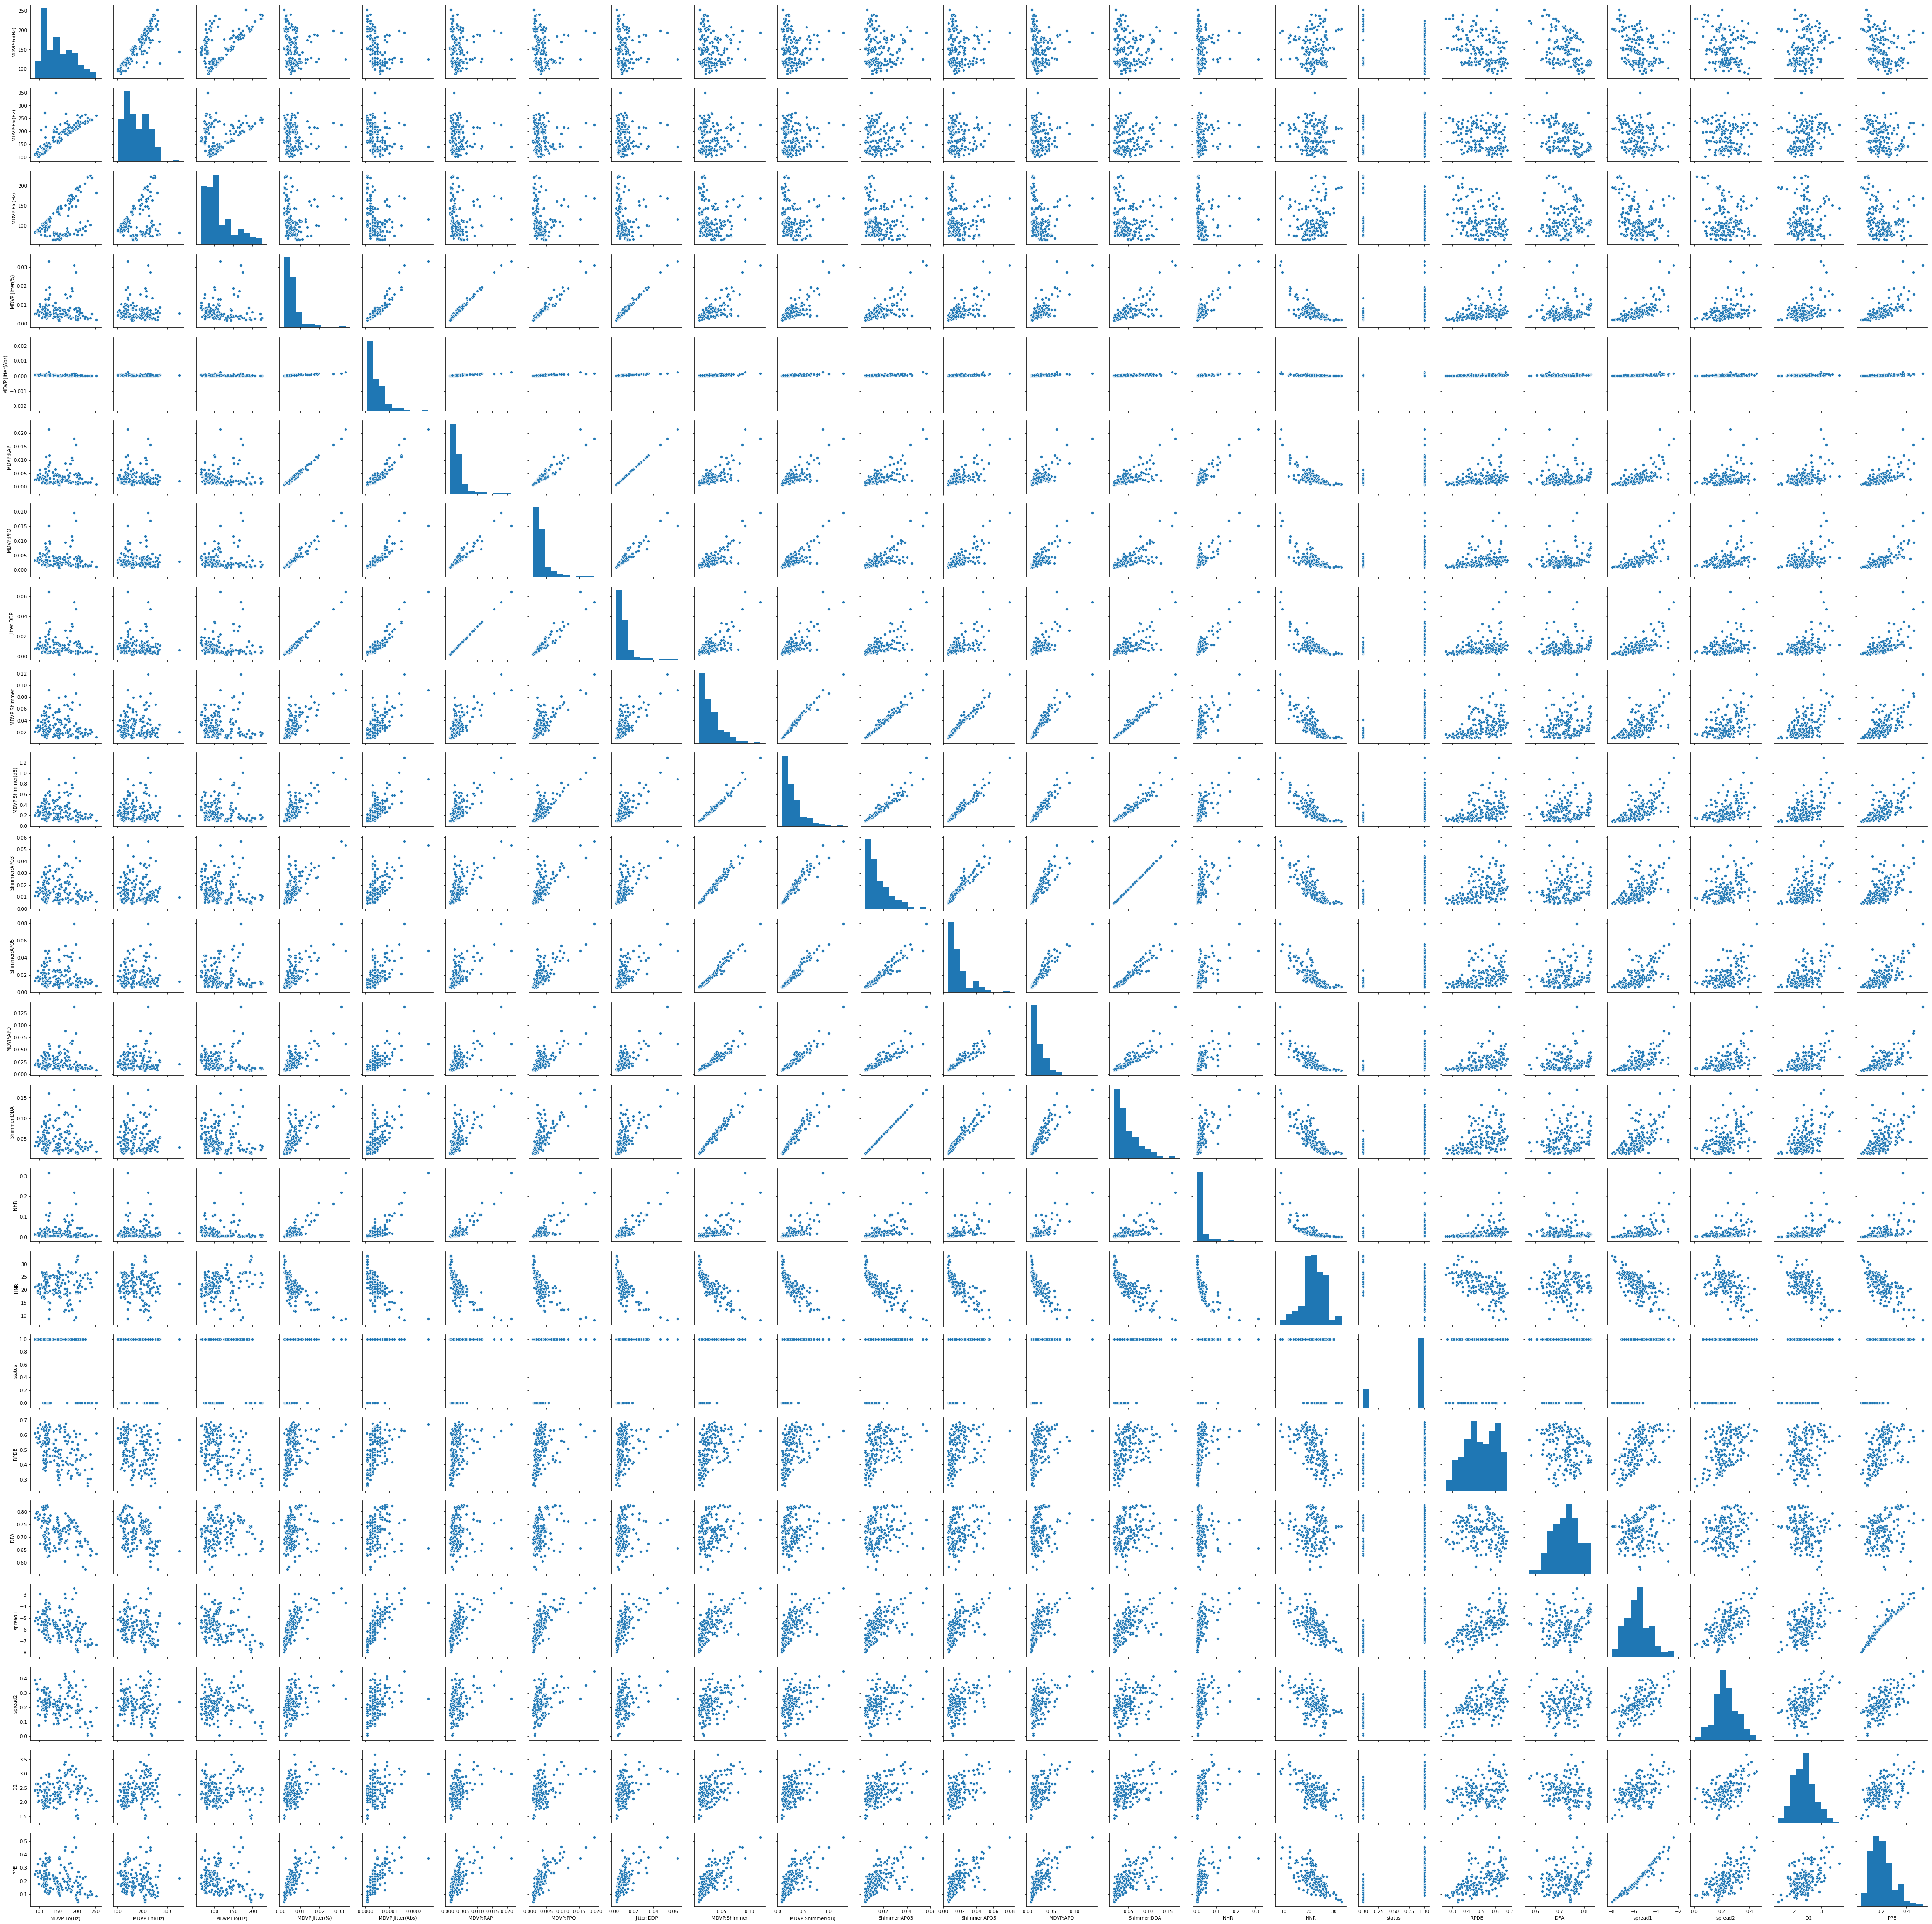

In [66]:
# Multivariate Analysis
sns.pairplot(df1)

Step 4. Split the dataset into training and test set in the ratio of 70:30 (Training:Test).

In [77]:
X = df1.drop("status", axis=1)
y = df1["status"]

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)


Step 5 - Create the model using “entropy” method of reducing the entropy and fit it to training data.
Step 6 - Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. 

In [78]:
X_train1=np.array(X_train)
y_train1=np.array(y_train)

X_test1=np.array(X_test)
y_test1=np.array(y_test)

In [101]:
model=DecisionTreeClassifier(max_depth=4,criterion='entropy',random_state=0)
model.fit(X_train1,y_train1)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

In [102]:
ypred=model.predict(X_test1)

In [103]:
acc=metrics.accuracy_score(y_test1,ypred)
print(acc)

0.7777777777777778


In [121]:
cm =metrics.confusion_matrix(y_test1,ypred)
print(cm)

[[ 5  2]
 [10 37]]


In [104]:
model1=DecisionTreeClassifier(criterion='entropy',random_state = 100,max_depth = 3, min_samples_leaf = 5)
model1.fit(X_train1,y_train1)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=3,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=5, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=100,
            splitter='best')

In [105]:
ypred1=model1.predict(X_test1)

In [106]:
acc1=metrics.accuracy_score(y_test1,ypred1)
print(acc1)

0.8518518518518519


In [120]:
cm1=metrics.confusion_matrix(y_test1,ypred1)
print(cm1)

[[ 5  2]
 [ 6 41]]


In [118]:
model2=DecisionTreeClassifier(criterion='entropy',random_state = 100,max_depth = 5, min_samples_leaf = 6)
model2.fit(X_train1,y_train1)
ypred2=model2.predict(X_test1)
acc2=metrics.accuracy_score(y_test1,ypred2)
print(acc2)

0.8518518518518519


In [119]:
cm2=metrics.confusion_matrix(y_test1,ypred2)
print(cm2)

[[ 5  2]
 [ 6 41]]


In [124]:
cr1=metrics.classification_report(y_test1,ypred)
print(cr1)

             precision    recall  f1-score   support

          0       0.33      0.71      0.45         7
          1       0.95      0.79      0.86        47

avg / total       0.87      0.78      0.81        54



In [122]:
cr1=metrics.classification_report(y_test1,ypred1)
print(cr1)

             precision    recall  f1-score   support

          0       0.45      0.71      0.56         7
          1       0.95      0.87      0.91        47

avg / total       0.89      0.85      0.87        54



In [123]:
cr1=metrics.classification_report(y_test1,ypred2)
print(cr1)

             precision    recall  f1-score   support

          0       0.45      0.71      0.56         7
          1       0.95      0.87      0.91        47

avg / total       0.89      0.85      0.87        54



cr2 has the best metrics 

In [125]:
print (pd.DataFrame(model2.feature_importances_, columns = ["Imp"], index = X_train_l.columns))


                       Imp
MDVP:Fo(Hz)       0.108218
MDVP:Fhi(Hz)      0.000000
MDVP:Flo(Hz)      0.000000
MDVP:Jitter(%)    0.050477
MDVP:Jitter(Abs)  0.000000
MDVP:RAP          0.000000
MDVP:PPQ          0.000000
Jitter:DDP        0.000000
MDVP:Shimmer      0.000000
MDVP:Shimmer(dB)  0.123064
Shimmer:APQ3      0.000000
Shimmer:APQ5      0.000000
MDVP:APQ          0.000000
Shimmer:DDA       0.000000
NHR               0.000000
HNR               0.000000
RPDE              0.091892
DFA               0.000000
spread1           0.526781
spread2           0.099568
D2                0.000000
PPE               0.000000


Step 7 - Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help?

In [126]:
#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,10),'criterion' : ['entropy','gini']}
GS=GridSearchCV(model,parameter,cv=3)
GS.fit(X,y)


GridSearchCV(cv=3, error_score='raise',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid=True, n_jobs=1,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [128]:
GS.score(X_test,y_test)

0.9629629629629629

In [129]:
gs_pred=GS.predict(X_test)

In [130]:
metrics.accuracy_score(y_test,gs_pred)

0.9629629629629629

In [131]:
GS.best_params_

{'criterion': 'gini', 'max_depth': 3}

In [165]:
GS

GridSearchCV(cv=3, error_score='raise',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid=True, n_jobs=1,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

Based on regularisation max_depth should be 3, min_sample_leaf = 1

In [166]:
model3=DecisionTreeClassifier(criterion='entropy',random_state = 100,max_depth = 3, min_samples_leaf = 1)
model3.fit(X_train1,y_train1)
ypred3=model2.predict(X_test1)
acc3=metrics.accuracy_score(y_test1,ypred3)
print(acc3)

0.8518518518518519


In [167]:
cm3=metrics.confusion_matrix(y_test,ypred3)
print(cm3)

[[ 5  2]
 [ 6 41]]


In [168]:
cr3=metrics.classification_report(y_test,ypred3)
print(cr3)

             precision    recall  f1-score   support

          0       0.45      0.71      0.56         7
          1       0.95      0.87      0.91        47

avg / total       0.89      0.85      0.87        54



Step 8 - Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? 

In [155]:
Rf_model = RandomForestClassifier(n_estimators=51,criterion='entropy',random_state=0 )

In [177]:
Rmodels = []
Rmodels.append(('DecisionTree', model2))
Rmodels.append(('RandomForest', Rf_model))

DecisionTree: 0.868052 (0.016676)
RandomForest: 0.938095 (0.004499)


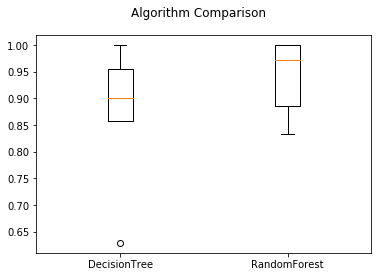

In [178]:
# evaluate each model in turn
results = []
names = []
scoring = 'recall'
for name, imodel in Rmodels:
	kfold = model_selection.KFold(n_splits=5,random_state=2)
	cv_results = model_selection.cross_val_score(imodel, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [179]:
results

[array([0.9       , 0.95454545, 0.85714286, 0.62857143, 1.        ]),
 array([0.83333333, 1.        , 0.88571429, 0.97142857, 1.        ])]

Optimal number of trees is 5 which will give the best result